# Parkinson's FOG - EDA and Model Submission

This notebook aims to achieve a reasonable result, with a glampse on the Data and quick modeling with cross validation.

# Importing necessary dependecies

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# EDA
## Reading the data

In [2]:
import glob
train_files = glob.glob("/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/train/tdcsfog/*.csv")
train_list = []
for f in tqdm(train_files):
    train_batch = pd.read_csv(f)
    train_list.append(train_batch)
train = pd.concat(train_list)

100%|██████████| 833/833 [00:17<00:00, 47.75it/s]


### Visualizing features

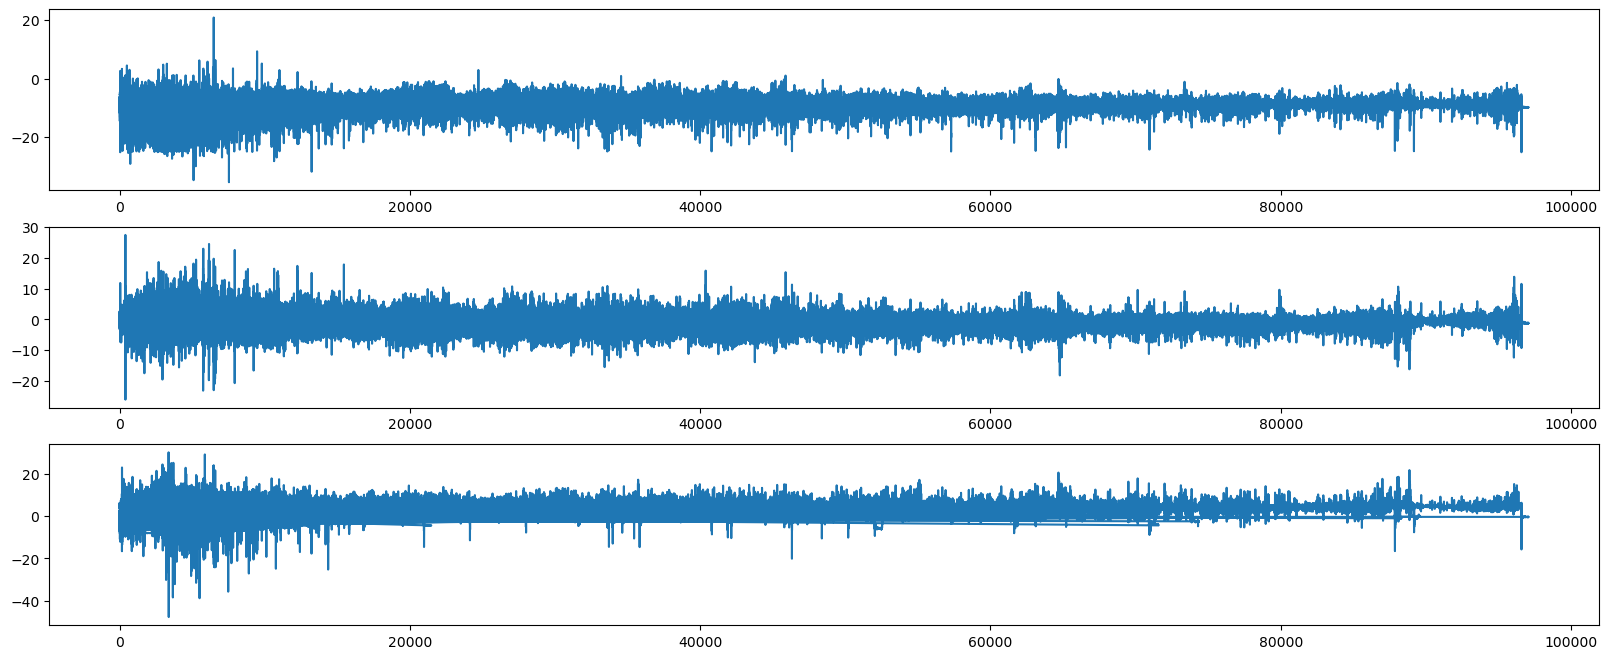

In [3]:
fig, ax = plt.subplots(3,1, figsize=(20,8))
train.AccV.plot(ax=ax[0])
train.AccML.plot(ax=ax[1])
train.AccAP.plot(ax=ax[2])
plt.show()

### Visualizing target vectors

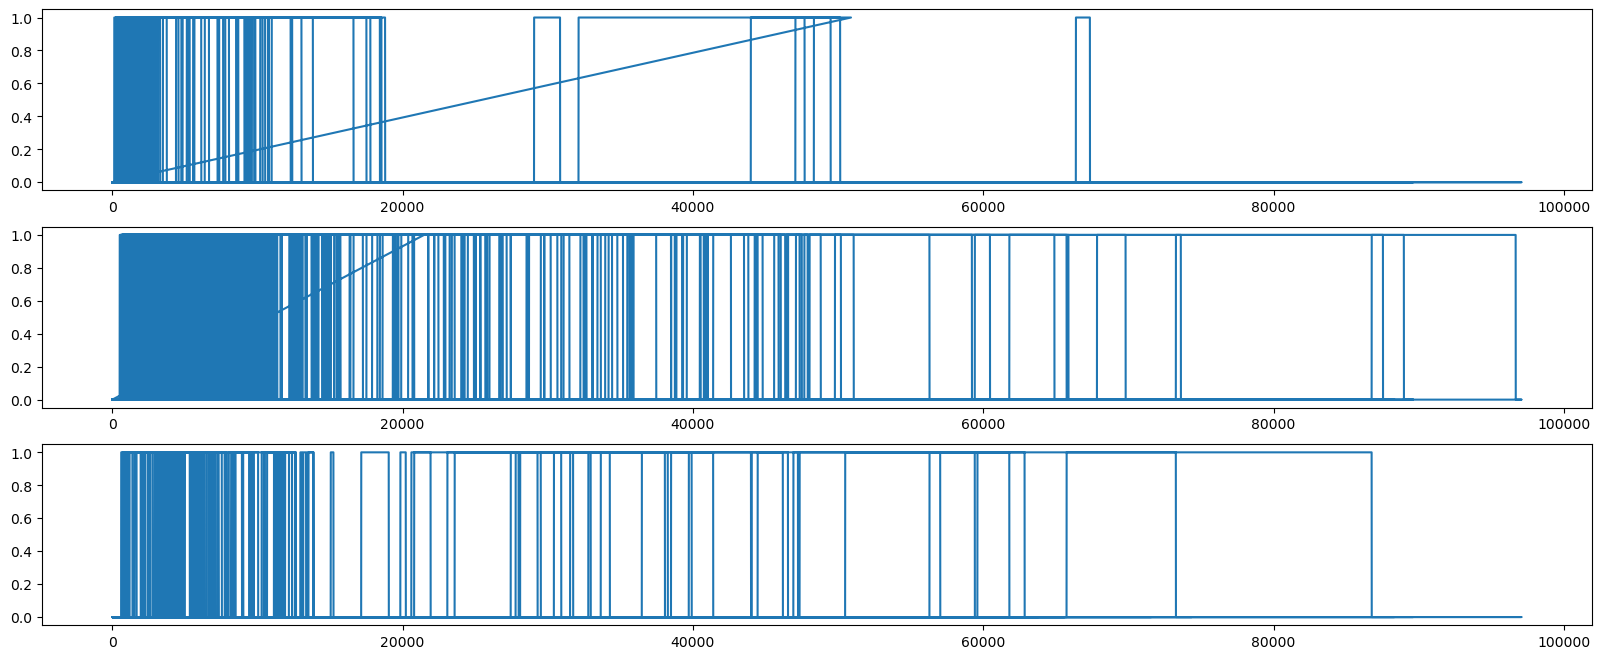

In [4]:
fig, ax = plt.subplots(3,1, figsize=(20,8))
train.StartHesitation.plot(ax=ax[0])
train.Turn.plot(ax=ax[1])
train.Walking.plot(ax=ax[2])
plt.show()

In [5]:
train.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06
mean,9.289467e+03,-9.306317e+00,-2.012513e-01,1.808524e+00,4.315506e-02,2.376979e-01,2.942767e-02
std,1.399893e+04,1.080174e+00,1.269525e+00,2.285849e+00,2.032061e-01,4.256731e-01,1.690020e-01
min,0.000000e+00,-3.552112e+01,-2.616440e+01,-4.782964e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.119000e+03,-9.762402e+00,-9.295446e-01,5.672254e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.310000e+03,-9.363524e+00,-1.722245e-01,1.987101e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.433000e+03,-8.776814e+00,5.752114e-01,3.449026e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,9.707600e+04,2.090695e+01,2.748472e+01,3.033769e+01,1.000000e+00,1.000000e+00,1.000000e+00


### From that we understand our mission is to classificate the time series signals between (StartHesitation, Turn and Walking)



## How do our features affect and correlate to our target classess?

### AccV relationship with StartHesitation, Turn and Walking

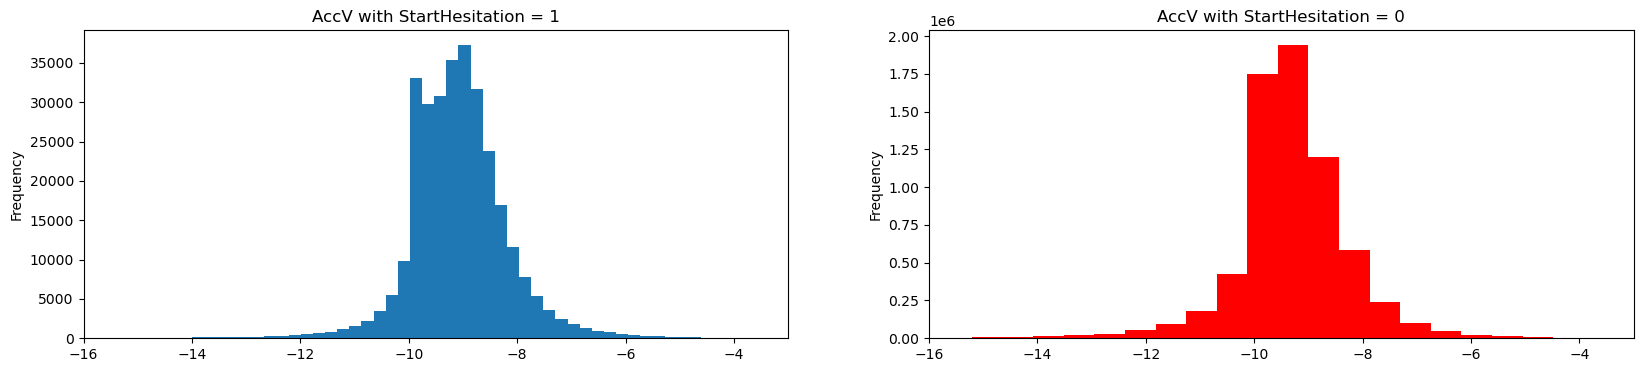

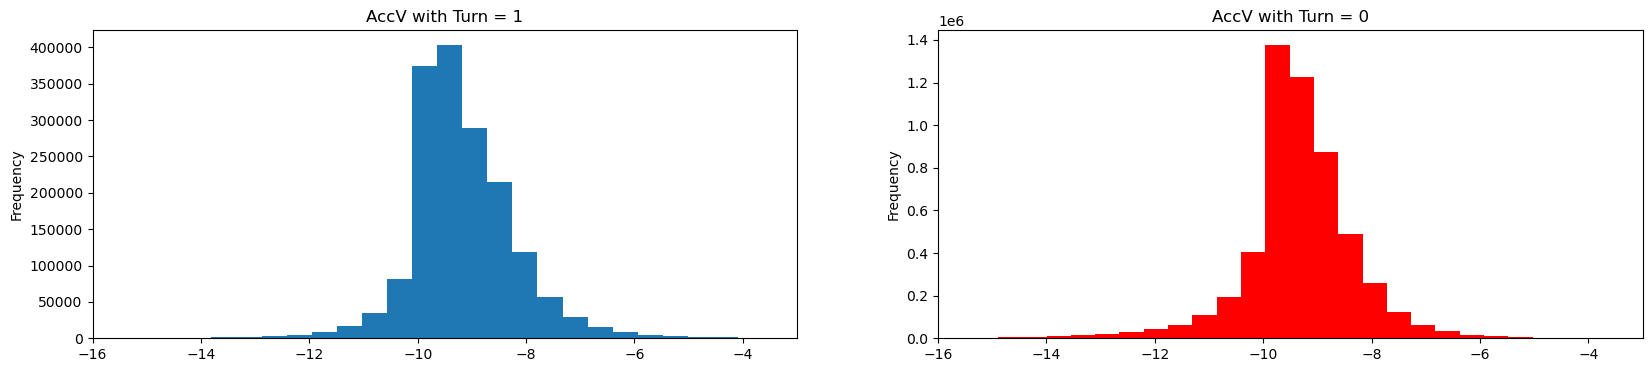

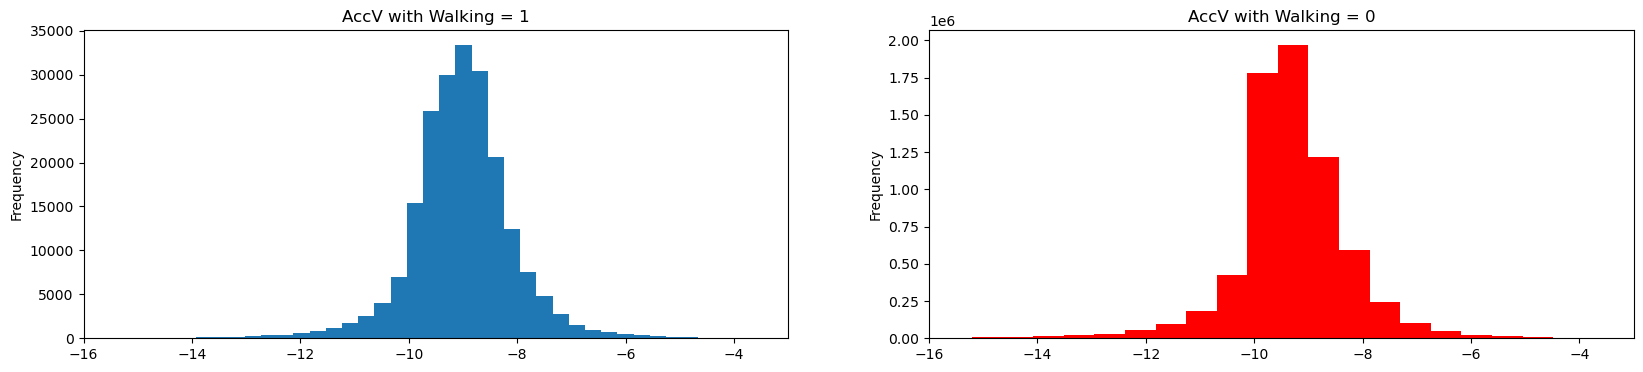

In [6]:
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.StartHesitation == 1].AccV.plot(kind='hist', title = 'AccV with StartHesitation = 1', ax =ax[0], bins=100, xlim=(-16,-3));
train.loc[train.StartHesitation == 0].AccV.plot(kind='hist', title = 'AccV with StartHesitation = 0', ax =ax[1], bins=100, xlim=(-16,-3), color='red');
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.Turn == 1].AccV.plot(kind='hist', title = 'AccV with Turn = 1', ax =ax[0], bins=100, xlim=(-16,-3));
train.loc[train.Turn == 0].AccV.plot(kind='hist', title = 'AccV with Turn = 0', ax =ax[1], bins=100, xlim=(-16,-3), color='red');
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.Walking == 1].AccV.plot(kind='hist', title = 'AccV with Walking = 1', ax =ax[0], bins=100, xlim=(-16,-3));
train.loc[train.Walking == 0].AccV.plot(kind='hist', title = 'AccV with Walking = 0', ax =ax[1], bins=100, xlim=(-16,-3), color='red');

### AccML relationship with StartHesitation, Turn and Walking

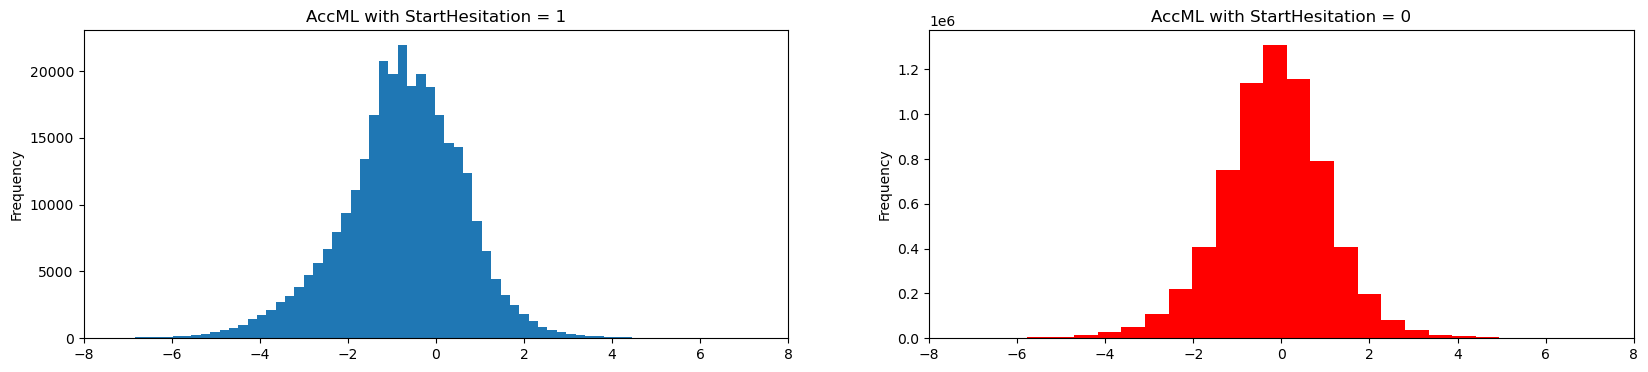

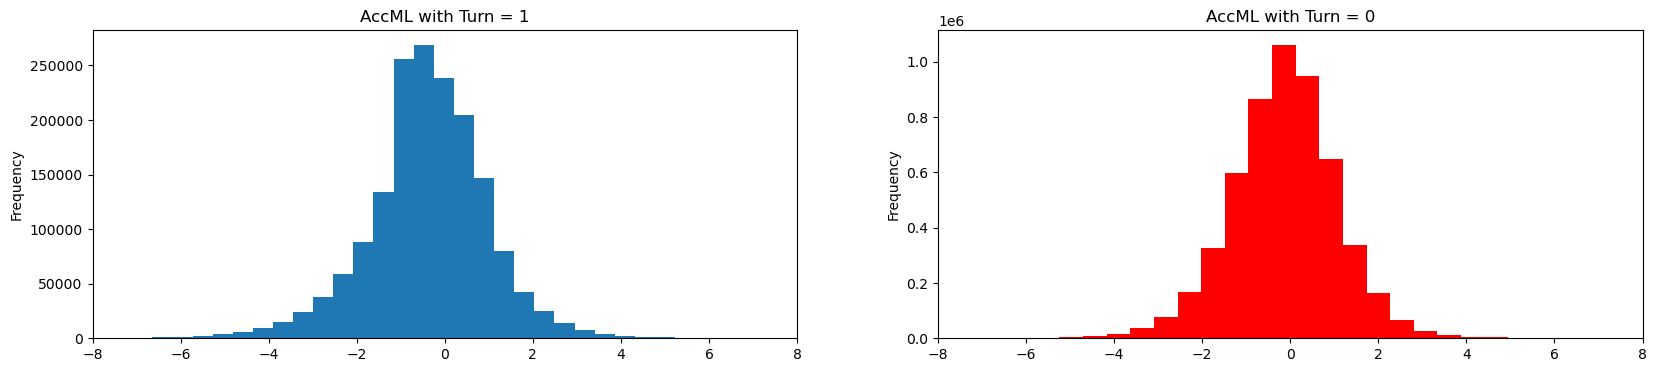

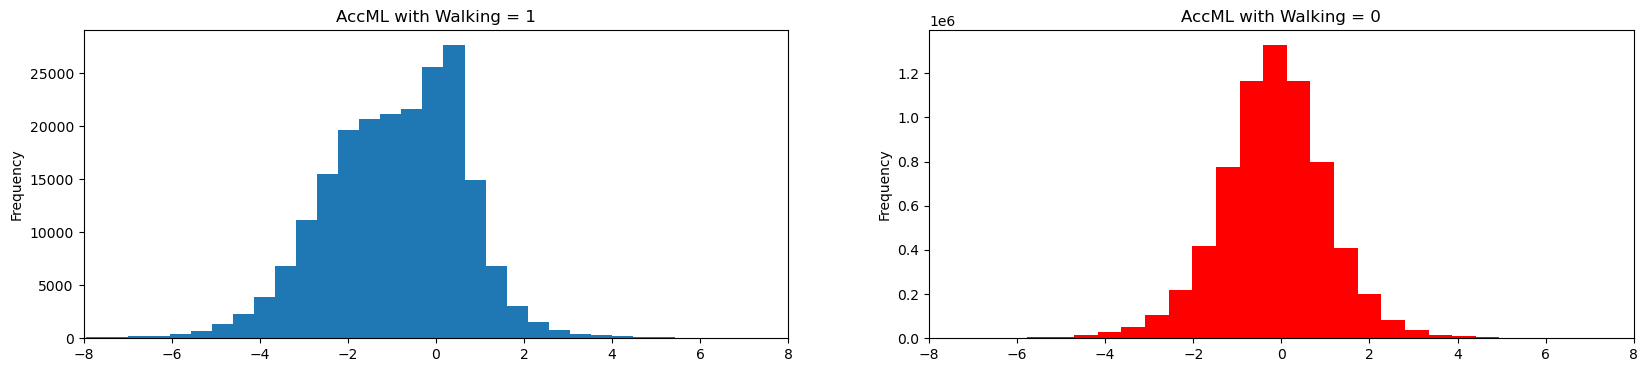

In [7]:
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.StartHesitation == 1].AccML.plot(kind='hist', title = 'AccML with StartHesitation = 1', ax =ax[0],xlim=(-8,8), bins=100,);
train.loc[train.StartHesitation == 0].AccML.plot(kind='hist', title = 'AccML with StartHesitation = 0', ax =ax[1],xlim=(-8,8), bins=100, color='red');
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.Turn == 1].AccML.plot(kind='hist', title = 'AccML with Turn = 1', ax =ax[0], bins=100, xlim=(-8,8));
train.loc[train.Turn == 0].AccML.plot(kind='hist', title = 'AccML with Turn = 0', ax =ax[1], bins=100, xlim=(-8,8), color='red');
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.Walking == 1].AccML.plot(kind='hist', title = 'AccML with Walking = 1', ax =ax[0], bins=100, xlim=(-8,8));
train.loc[train.Walking == 0].AccML.plot(kind='hist', title = 'AccML with Walking = 0', ax =ax[1], bins=100, xlim=(-8,8), color='red');

### AccAP relationship with StartHesitation,Turn and Walking

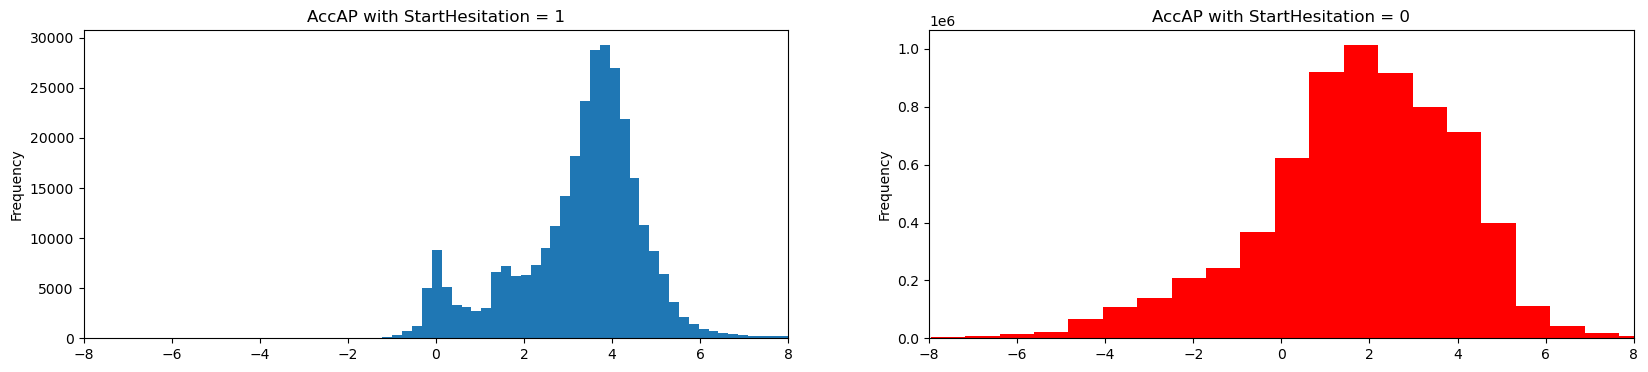

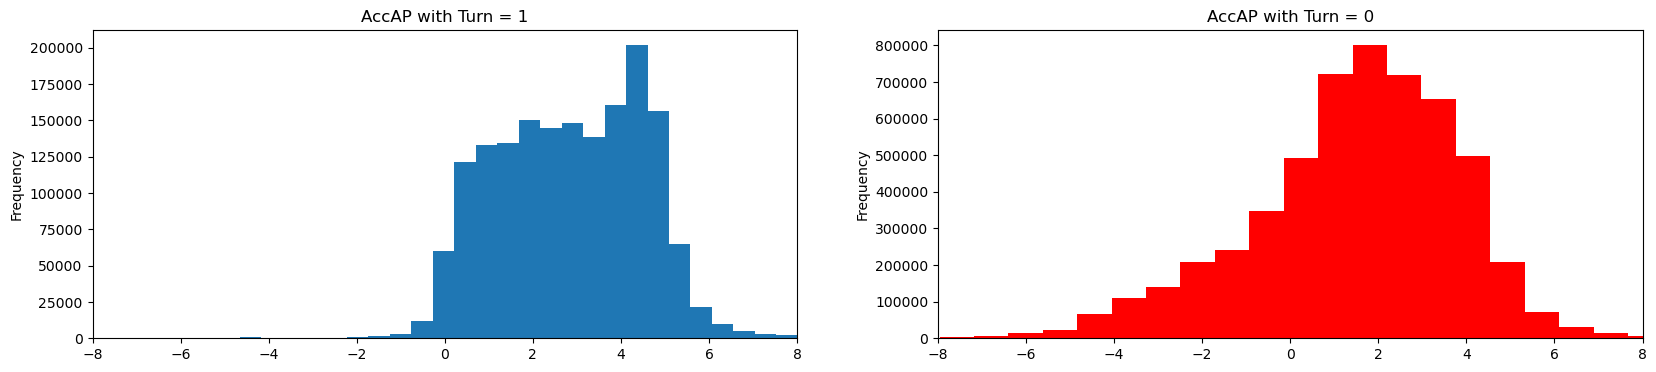

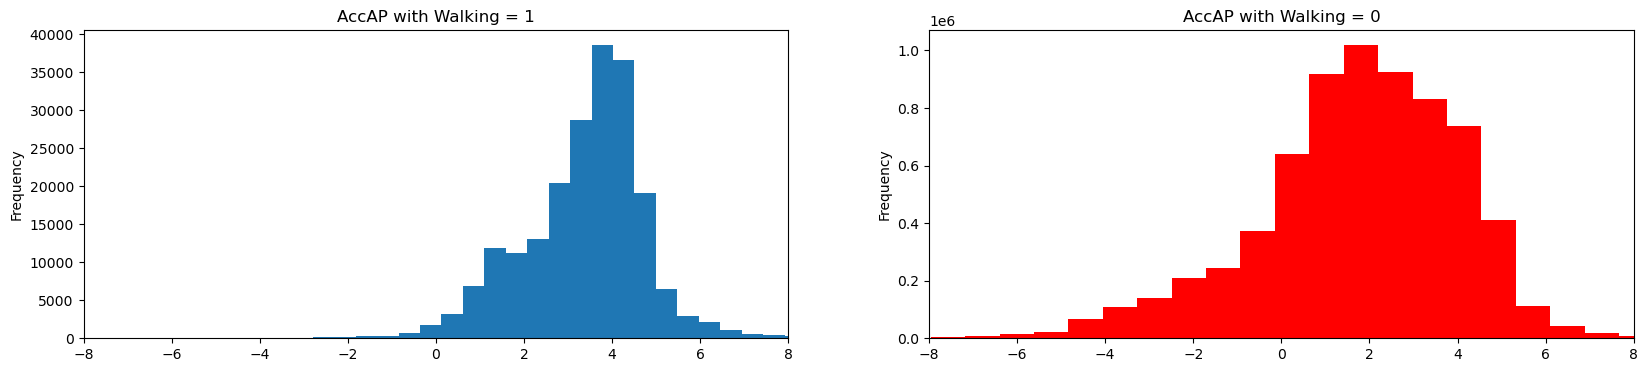

In [8]:
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.StartHesitation == 1].AccAP.plot(kind='hist', title = 'AccAP with StartHesitation = 1', ax =ax[0],xlim=(-8,8), bins=100,);
train.loc[train.StartHesitation == 0].AccAP.plot(kind='hist', title = 'AccAP with StartHesitation = 0', ax =ax[1],xlim=(-8,8), bins=100, color='red');
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.Turn == 1].AccAP.plot(kind='hist', title = 'AccAP with Turn = 1', ax =ax[0], bins=100, xlim=(-8,8));
train.loc[train.Turn == 0].AccAP.plot(kind='hist', title = 'AccAP with Turn = 0', ax =ax[1], bins=100, xlim=(-8,8), color='red');
fig, ax = plt.subplots(1,2, figsize=(20,4));
train.loc[train.Walking == 1].AccAP.plot(kind='hist', title = 'AccAP with Walking = 1', ax =ax[0], bins=100, xlim=(-8,8));
train.loc[train.Walking == 0].AccAP.plot(kind='hist', title = 'AccAP with Walking = 0', ax =ax[1], bins=100, xlim=(-8,8), color='red');

## Feature correlation with our Target Classes

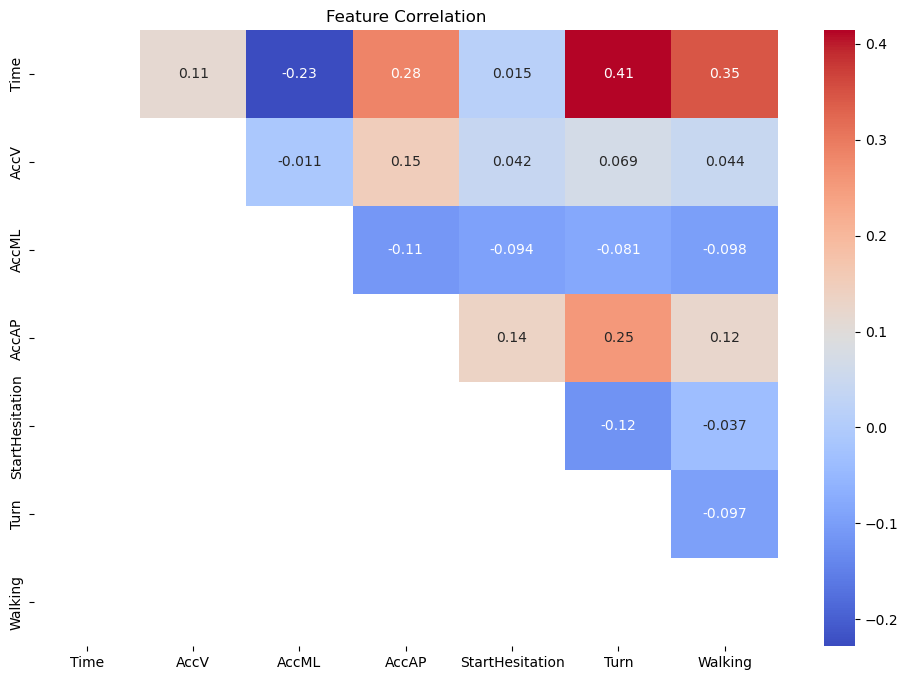

In [9]:
corr_matrix = train.corr()

# Plot correlation matrix as a heatmap
plt.figure(figsize=(12,8));
plt.title('Feature Correlation');
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask.T);

#### From the analysis of the relationship between our features and our target classes, we observe:
*  AccML has an inverse relationship to our target classes
*  AccAP has a positive relationship to our targets
*  AccV presents low correlation to our classes
* Time has a STRONG positive relationship with TURN and WALKING.

### Are the target vectors balanced

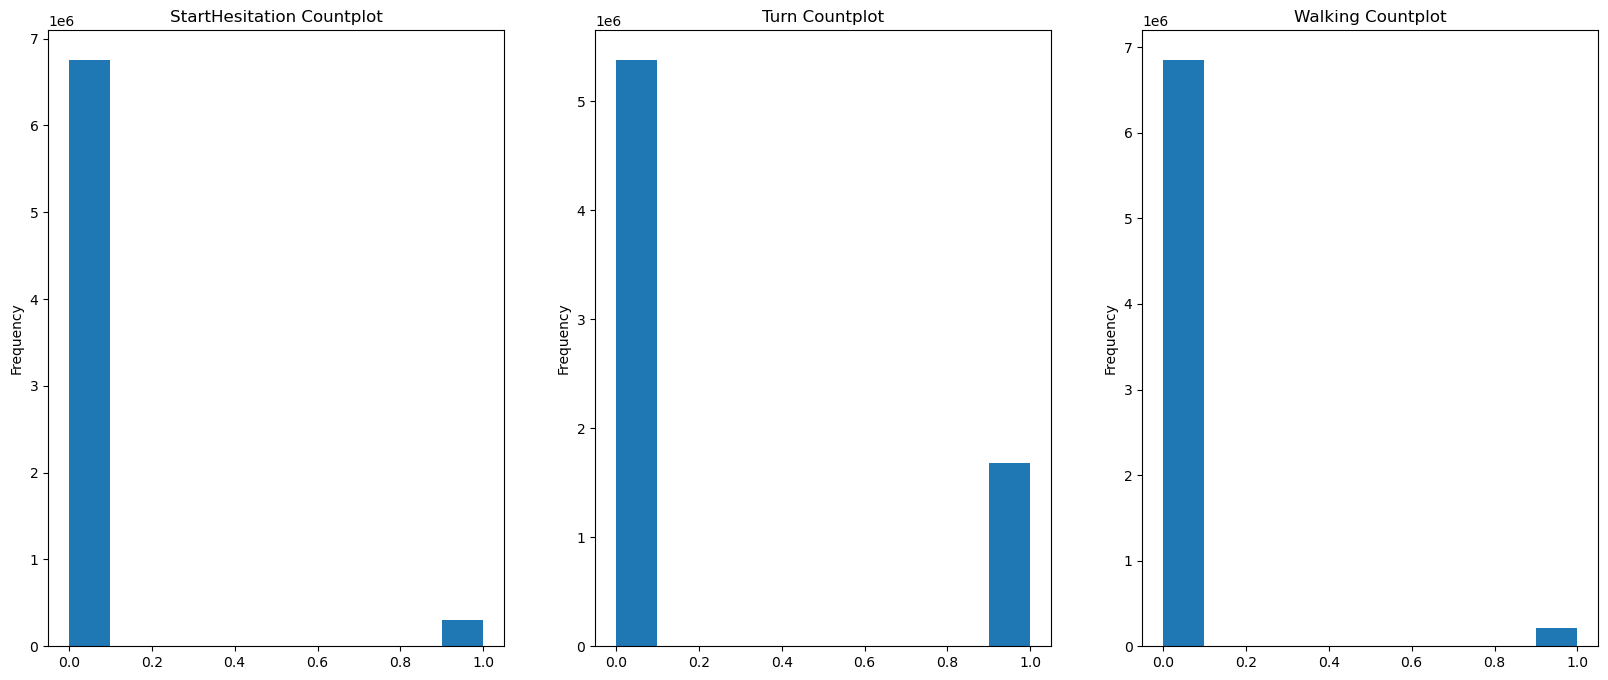

In [10]:
fig, ax = plt.subplots(1,3, figsize=(20,8))
train[['StartHesitation', 'Turn', 'Walking']].StartHesitation.plot(kind='hist', ax=ax[0], title = 'StartHesitation Countplot')
train[['StartHesitation', 'Turn', 'Walking']].Turn.plot(kind='hist', ax = ax[1], title = 'Turn Countplot')
train[['StartHesitation', 'Turn', 'Walking']].Walking.plot(kind='hist', ax = ax[2], title = 'Walking Countplot')
plt.show()

#### It seems they are not balanced, we should deal with this problem using undersampling or class weights.

### We can see that "StartHesitation","Turn","Walking" are actually mutually exclusive

In [11]:
print('_'*25)
print('When StartHesitation = 1\n',train.loc[train['StartHesitation'] == 1][['Walking', 'Turn']].value_counts(),'\n')
print('_'*25)
print('When Turn = 1\n',train.loc[train['Walking'] == 1][['StartHesitation', 'Turn']].value_counts(),'\n')
print('_'*25)
print('When Walking = 1\n',train.loc[train['Turn'] == 1][['StartHesitation', 'Walking']].value_counts(),'\n')

_________________________
When StartHesitation = 1
 Walking  Turn
0        0       304790
dtype: int64 

_________________________
When Turn = 1
 StartHesitation  Turn
0                0       207838
dtype: int64 

_________________________
When Walking = 1
 StartHesitation  Walking
0                0          1678782
dtype: int64 



#### That meas we could have a multiclass objective, instead of multioutput classification objective....

# Feature Engineering

As our model should be able to clasify timeseries between StartHesitation, Turn and Walking, we can take advantage of clustering algorithm in order to segment diferent time series caracteristics

In [12]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder


# Step 1: Choose clustering algorithm
cluster_algo = KMeans(n_clusters=4) #-> We want to identify 4 diferent classes (StartHesitation, Turn, Walking or None)  

# Step 2: Select relevant features
selected_features = ['Time','AccV', 'AccML','AccAP']  

# Step 3: Perform clustering
cluster_labels = cluster_algo.fit_predict(train[selected_features])  # data is your original dataset

# Step 4: Encode cluster labels as features
encoder = OneHotEncoder(sparse=False)
cluster_features = encoder.fit_transform(cluster_labels.reshape(-1, 1))

# Step 5: Combine cluster features with original features
augmented_data = np.hstack((train, cluster_features))  # Augmented dataset with original and cluster features

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [13]:
pd.Series(cluster_labels).value_counts()

1    5614806
0     783574
3     471680
2     192612
dtype: int64

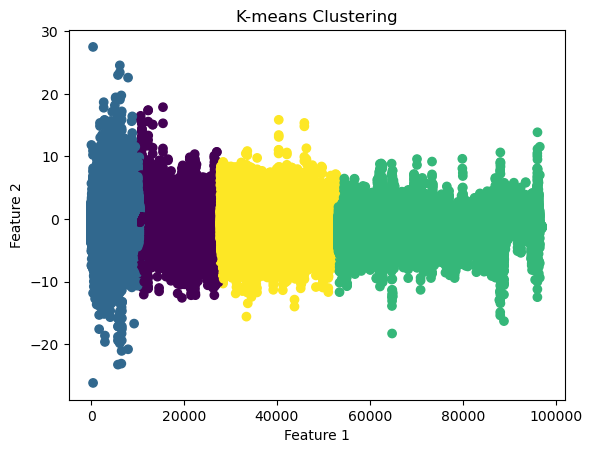

In [14]:
feature1 = train[:].Time
feature2 = train[:].AccML

# Plot the clusters
plt.scatter(feature1, feature2, c=cluster_labels, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-means Clustering')
plt.show()

In [15]:
train['Cluster'] = cluster_labels

In [16]:
train.loc[train.Cluster == 1][['StartHesitation', 'Turn', 'Walking']].value_counts()

StartHesitation  Turn  Walking
0                0     0          4606154
                 1     0           742240
1                0     0           221003
0                0     1            45409
dtype: int64

## Processing pipeline

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Define the preprocessing pipeline
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),        # Handling missing data
    ('scaler', StandardScaler()),                       # Standardizing the data
    ('sampler', RandomUnderSampler(random_state=42)),    # Random under-sampling
])

### Enabling multiclass classification

In [18]:
train['Class'] =  (train['StartHesitation'] * 1) + (train['Turn'] * 2) + (train['Walking'] * 3)


<Axes: >

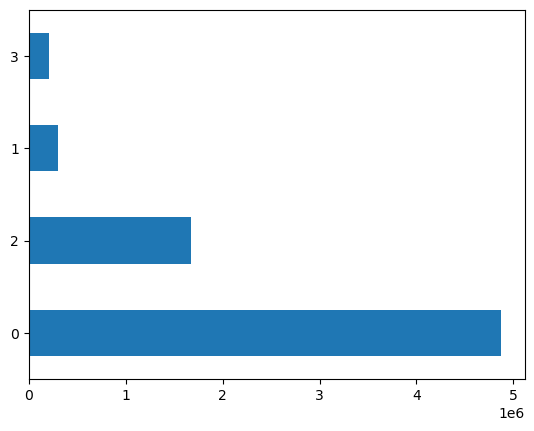

In [19]:
train.Class.value_counts().plot(kind='barh')

# Training simple model

In [20]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

import xgboost as xgb
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

def xgb_params(imbalance_ratio:float) -> dict:
    params = {
        "tree_method": "gpu_hist",
        "objective": "binary:logistic",
        'eval_metric': 'auc',
        'scale_pos_weight': imbalance_ratio,
        'learning_rate': 0.1,
        'max_depth': 5,
        'min_child_weight': 1,
        'gamma': 0,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0,
        'reg_lambda': 1,
        'n_estimators': 100,
        'random_state': 42
    }
    return params

def train_multioutput_classifier(X, y, num_classes):
    tscv = StratifiedKFold(n_splits=10)  # Define time series cross-validator

    models = []  # List to store models for each output
    train_losses = []  # List to store training losses
    val_losses = []  # List to store validation losses

    for i in range(num_classes):
        print('_'*50)
        print("Training model for Class ", i)
        imbalance_ratio = pd.Series(y[:, i]).value_counts()[0]/pd.Series(y[:, i]).value_counts()[1]
        params = xgb_params(imbalance_ratio)
        model = xgb.XGBClassifier(**params)

        output_labels = y[:, i]  # Select labels for the current output
        train_loss_fold = []  # Training loss for each fold
        val_loss_fold = []  # Validation loss for each fold

        for train_index, test_index in tqdm(tscv.split(X,output_labels)):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = output_labels[train_index], output_labels[test_index]

            model.fit(X_train, y_train)

            y_pred_proba_train = model.predict_proba(X_train)[:, 1]
            y_pred_proba_val = model.predict_proba(X_test)[:, 1]

            train_loss = average_precision_score(y_train, y_pred_proba_train)
            print("Train Loss: ", train_loss)
            val_loss = average_precision_score(y_test, y_pred_proba_val)
            print("Val Loss: ", val_loss)

            train_loss_fold.append(train_loss)
            val_loss_fold.append(val_loss)

        models.append(model)
        train_losses.append(train_loss_fold)
        val_losses.append(val_loss_fold)
        print("Train Losses: ", train_losses)
        print("Val Losses: ", val_losses)


    return models, train_losses, val_losses

def xgb_multi_params(imbalance_ratio: float) -> dict:
    params = {
        "tree_method": "gpu_hist",
        "objective": "multi:softmax",
        'eval_metric': 'mlogloss',
        'scale_pos_weight': imbalance_ratio,
        'learning_rate': 0.1,
        'max_depth': 5,
        'min_child_weight': 1,
        'gamma': 0,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0,
        'reg_lambda': 1,
        'num_class': 3,  # Number of classes
        'n_estimators': 100,
        'random_state': 42
    }
    return params
def calculate_map(y_true, y_pred_proba):
    num_classes = y_pred_proba.shape[1]
    map_scores = []
    
    for class_index in range(num_classes):
        y_true_class = (y_true == class_index).astype(int)
        y_pred_class = y_pred_proba[:, class_index]
        
        ap_score = average_precision_score(y_true_class, y_pred_class)
        map_scores.append(ap_score)
    
    mAP = np.mean(map_scores)
    return mAP

def train_multiclass_classifier(X, y):
    skf = StratifiedKFold(n_splits=10)  # Define stratified cross-validator

    models = []  # List to store models for each class
    train_losses = []  # List to store training losses
    val_losses = []  # List to store validation losses

    y_combined = y  # Combine the boolean columns into a single integer column

    print('_' * 50)
    print("Training model for Multiclass Classification")

    imbalance_ratio = pd.Series(y_combined).value_counts()[0] / pd.Series(y_combined).value_counts()[1]
    params = xgb_multi_params(imbalance_ratio)
    model = xgb.XGBClassifier(**params)

    train_loss_fold = []  # Training loss for each fold
    val_loss_fold = []  # Validation loss for each fold

    for train_index, test_index in tqdm(skf.split(X, y_combined)):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_combined[train_index], y_combined[test_index]

        model.fit(X_train, y_train)

        y_pred_proba_train = model.predict_proba(X_train)
        y_pred_proba_val = model.predict_proba(X_test)

        train_loss = calculate_map(y_train, y_pred_proba_train)  # Assuming binary classification
        print("Train Loss: ", train_loss)
        val_loss = calculate_map(y_test, y_pred_proba_val)  # Assuming binary classification
        print("Val Loss: ", val_loss)

        train_loss_fold.append(train_loss)
        val_loss_fold.append(val_loss)

    models.append(model)
    train_losses.append(train_loss_fold)
    val_losses.append(val_loss_fold)
    print("Train Losses: ", train_losses)
    print("Val Losses: ", val_losses)

    return models, train_losses, val_losses

In [21]:
train.columns

Index(['Time', 'AccV', 'AccML', 'AccAP', 'StartHesitation', 'Turn', 'Walking',
       'Cluster', 'Class'],
      dtype='object')

In [22]:
# Train our simple model
X = train[['AccV', 'AccML','AccAP', 'Cluster']].values
y = train['Class'].values#['StartHesitation', 'Turn', 'Walking']].values
num_classes = 3

# Fit and transform the training data
X, y = preprocessing_pipeline.fit_resample(X, y)

models, train_losses, val_losses = train_multiclass_classifier(X, y)#, num_classes)
# Plot training and validation losses
#fig, axes = plt.subplots(nrows=num_classes, figsize=(8, 6*num_classes))

#for i, ax in enumerate(axes):
#    ax.plot(range(len(train_losses[i])), train_losses[i], label='Train')
#    ax.plot(range(len(val_losses[i])), val_losses[i], label='Validation')
#    ax.set_xlabel('Fold')
#    ax.set_ylabel('Loss')
#    ax.set_title('Output {}'.format(i+1))
#    ax.legend()

#plt.tight_layout()
#plt.show()

__________________________________________________
Training model for Multiclass Classification


0it [00:00, ?it/s]

[00:39:52] WARNING: ../src/learner.cc:767: 
Parameters: { "scale_pos_weight" } are not used.



1it [00:08,  8.18s/it]

Train Loss:  0.6604688566987356
Val Loss:  0.5853897366389802
[00:39:58] WARNING: ../src/learner.cc:767: 
Parameters: { "scale_pos_weight" } are not used.



...

Train Loss:  0.6503901401689843
Val Loss:  0.6861917289550347
[00:40:47] WARNING: ../src/learner.cc:767: 
Parameters: { "scale_pos_weight" } are not used.



9it [01:03,  6.96s/it]

Train Loss:  0.648887722734566
Val Loss:  0.7056600901931902
[00:40:54] WARNING: ../src/learner.cc:767: 
Parameters: { "scale_pos_weight" } are not used.



10it [01:10,  7.06s/it]

Train Loss:  0.6438293866991038
Val Loss:  0.734838265490803
Train Losses:  [[0.6604688566987356, 0.6567413979323202, 0.6548538189020768, 0.6644706445254773, 0.6590070368948504, 0.6635952153744553, 0.662414125220667, 0.6503901401689843, 0.648887722734566, 0.6438293866991038]]
Val Losses:  [[0.5853897366389802, 0.6166640568964811, 0.6491180606016294, 0.5347444149344299, 0.6158504933269225, 0.5151085597139593, 0.5725902857067303, 0.6861917289550347, 0.7056600901931902, 0.734838265490803]]


In [23]:
import numpy as np

print("Mean Train Precision",np.mean(train_losses))
print("Mean Validation Precision",np.mean(val_losses))

Mean Train Precision 0.6564658345151237
Mean Validation Precision 0.6216155692458161


#### It already seems our model's prediction power is better than flipping a coin, at least at local CV 😂

## Sample submission

In [24]:
test_files = glob.glob("/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/test/*/*")
test_list = []
for f in tqdm(test_files):
    test_batch = pd.read_csv(f)
    test_list.append(test_batch)
test = pd.concat(test_list)
test.reset_index(inplace=True, drop = True)

100%|██████████| 2/2 [00:00<00:00,  5.33it/s]


In [25]:
# Step 1: Perform clustering inference on the test set
test_cluster_labels = cluster_algo.predict(test[selected_features])

# Step 2: Encode cluster labels as features
test_cluster_features = encoder.transform(test_cluster_labels.reshape(-1, 1))

# Step 3: Combine cluster features with original features
augmented_test_data = np.hstack((test, test_cluster_features))  # Augmented test dataset with original and cluster features

In [26]:
test['Cluster'] = test_cluster_labels

In [27]:
#preds = dict()
#probs = dict()
X_TEST = test[['AccV', 'AccML','AccAP', 'Cluster']].values
#for Class, model in enumerate(models):
#    print('_'*25)
#   print('Inference for Class: ',Class)
#    preds.update({Class:model.predict(X_TEST)})
#    probs.update({Class:model.predict_proba(X_TEST)})
#    print('DONE')

preds = models[0].predict(X_TEST)
probs = models[0].predict_proba(X_TEST)
    

In [28]:
preds = pd.DataFrame(preds)

In [29]:
preds.columns = ['Class']

In [30]:
preds['StartHesitation'] = 0
preds['Turn'] = 0 
preds['Walking'] = 0

In [31]:
preds.loc[preds['Class'] == 1, 'StartHesitation'] = 1
preds.loc[preds['Class'] == 2, 'Turn'] = 1
preds.loc[preds['Class'] == 3, 'Walking'] = 1

In [32]:
preds.value_counts()

Class  StartHesitation  Turn  Walking
3      0                0     1          239379
0      0                0     0           32769
2      0                1     0           14203
1      1                0     0              19
dtype: int64

In [33]:
probs = pd.DataFrame(probs)
probs.columns = ['0', 'StartHesitation', 'Turn', 'Walking']
probs

,0,StartHesitation,Turn,Walking
0,0.510963,0.132414,0.305931,0.050692
1,0.510963,0.132414,0.305931,0.050692
2,0.492463,0.144301,0.315796,0.047440
3,0.522537,0.124229,0.303048,0.050186
4,0.518716,0.124812,0.306254,0.050218
...,...,...,...,...
286365,0.972206,0.004764,0.011329,0.011700
286366,0.970999,0.004722,0.012236,0.012043
286367,0.972636,0.004748,0.011256,0.011361
286368,0.972206,0.004764,0.011329,0.011700


In [34]:
sub = pd.read_csv('/kaggle/input/tlvmc-parkinsons-freezing-gait-prediction/sample_submission.csv')

In [35]:
#probs[0][:,1]

In [36]:
sub['StartHesitation'] = preds['StartHesitation']#probs[0][:,1]
sub['Turn'] = preds['Turn']#[1][:,1]
sub['Walking'] = preds['Walking'] #[2][:,1]

In [37]:
sub.head()

,Id,StartHesitation,Turn,Walking
0,003f117e14_0,0,0,0
1,003f117e14_1,0,0,0
2,003f117e14_2,0,0,0
3,003f117e14_3,0,0,0
4,003f117e14_4,0,0,0


In [38]:
sub.to_csv('submission.csv', index=False)

### Considerations for further improvement
#### The proposal of this notebook is to provide a quick EDA and Sample model submission with some robustness to the problem of class imbalance.
We assumed some premisses in order to perform this study:
* TDSCFOG has better quality information, since it was collected in a controled environment. Hence it would be possible to predict DEFOG from TDCSFOG. Althought it would probably be better to train a sample model focused only on the DEFOG series...
* Eventhough our features have a time-series datastructure, our model can and might outperform time-series approaches, if we consider our objective to be a multiclass/multiouput classification model.
* It is possible to classify FOG events, just using telemetry (iot sensors) data. Therefore we are not considering events, tasks ans subjects informations. Nevertheless these data could improve our results....

TODO: Possible improvements:
* Merge events, tasks and subjects dataset to the training set
* Perform PCA in training set, before using KMEANs, this could possibily improve clustering performance
* Try diferent techniques for handling imbalanced data
* Train diferent model for the DEFOG dataset
* Add TimeSeries related Features
* Tryout diferent algorithms and hyperparameter tunning